# Solving Dirichlet Problem with Random Walks and Monte Carlo

**An annular Dirichlet problem: mathematical foundations, implementation, and error analysis**

This project approximates a harmonic function using random walks on a Cartesian grid. It connects partial differential equations, finite differences, absorbing Markov chains, and statistical estimation. A closed-form solution and a sparse linear solver provide two separate references: the continuous solution measures total error, while the discrete solution isolates Monte Carlo error.

The implementation uses **Python, NumPy, Matplotlib, and SciPy**. It progresses from a readable single-walk algorithm to vectorized simulation, repeated convergence experiments, and reconstruction of the full field.

### Reproducibility and scope

Run all cells from top to bottom in a fresh kernel. If needed, install dependencies in a notebook cell with `%pip install numpy matplotlib scipy`. Seeds are fixed for reproducibility; changing the order of random-number calls changes the sample paths. The larger experiment uses 12 repetitions of 200,000 walks, and the full-field example uses 2,000 walks per continuation node, so these sections take longer.

This is a numerical study of one boundary treatment, not a general-purpose PDE solver. The mathematical statements below distinguish exact identities, asymptotic estimates, and empirical observations.

## 1. Continuous problem and exact solution

Let
$$D=\{(x,y)\in\mathbb R^2:1<r<3\},\qquad r=\sqrt{x^2+y^2}.$$
We seek $u\in C^2(D)\cap C(\overline D)$ satisfying
$$\Delta u=0\quad\text{in }D,\qquad u|_{r=1}=4,\qquad u|_{r=3}=6.$$

The maximum principle implies uniqueness: the difference of two solutions is harmonic with zero boundary data. Since rotations preserve both the domain and the data, uniqueness implies that the solution is radial. Writing $u(x,y)=v(r)$ gives
$$v''(r)+\frac1r v'(r)=0\iff (rv'(r))'=0.$$
Hence $v(r)=a+b\log r$. The two boundary conditions yield
$$\boxed{u(x,y)=4+\frac{2\log r}{\log3}},\qquad
u(2,0)=4+\frac{2\log2}{\log3}\approx5.261859507.$$
Direct substitution verifies existence as well as the formula.\\
For more on harmonic functions and the Dirichlet problem for Laplace's equation see *Partial Differential Equations* by Lawrence C. Evans (American Mathematical Society) [1](#references)

**Intuition.** This is the equilibrium temperature between an inner circle held at 4 and an outer circle held at 6, with no heat sources in the annulus.

### Notation

| Symbol | Meaning |
|---|---|
| $N$, $h=6/N$ | Number of grid intervals per axis and grid spacing |
| $I_N$, $B_N$ | Continuation nodes and accessible absorbing nodes |
| $g_N$ | Discrete boundary data, taking values 4 and 6 |
| $U^{(N)}(z)$ | Discrete solution at any node $z$ |
| $U_N=U^{(N)}(z_N)$ | Discrete value at the starting node nearest to $(2,0)$ |
| $\widehat U_{N,M}$ | Estimate based on $M$ walks on the grid of resolution $N$ |

We use $D$ for the physical domain and $\mathcal W_N$ for the sample space of trajectories. All resolutions in the experiments are multiples of 6, so $z_N=(2,0)$ exactly in the mathematical grid.

## 2. Discretization of the problem

Fix $h=6/N$ and $(x_i,y_j)=(-3+ih,-3+jh)$ for $0\le i,j\le N$. If $u$ has bounded fourth derivatives in a neighborhood of the stencil, Taylor's theorem gives
$$u(x\pm h,y)=u\pm hu_x+\frac{h^2}{2}u_{xx}\pm\frac{h^3}{6}u_{xxx}+O(h^4).$$
Adding the two expansions cancels the odd terms. Doing the same in $y$ yields
$$\Delta_h u(z):=\frac{\sum_{w\sim z}u(w)-4u(z)}{h^2}
=\Delta u(z)+O(h^2),$$
where $w\sim z$ denotes one of the four nearest neighbors. Therefore $\Delta_h U=0$ is equivalent to the discrete mean-value property
$$U(z)=\frac14\sum_{w\sim z}U(w).$$
This is a discrete analogue of the mean-value property of harmonic functions.

### The boundary used by the algorithm

Let $G_N$ be the grid in $[-3,3]^2$. Define
$$I_N=\{z\in G_N\cap D:z\pm he_1,z\pm he_2\in D\}.$$
Let $B_N$ contain all neighbors of $I_N$ that are not in $I_N$. A walk stops as soon as it reaches $B_N$. The implementation also labels other grid nodes for convenience, but unreachable labels do not affect a walk started in $I_N$.

We prescribe $g_N=4$ or 6 on these absorbing nodes according to the nearest circle. Thus we approximate both the operator and the location where the boundary data are imposed. Second-order consistency of the interior stencil alone does not imply second-order global accuracy.

### Linear system and uniqueness

Numbering the nodes in $I_N$ gives
$$4U(z)-\sum_{w\sim z,\,w\in I_N}U(w)
=\sum_{w\sim z,\,w\in B_N}g_N(w),\qquad A\mathbf U=\mathbf b.$$
The diagonal entries of $A$ are 4 and interiorn eighbor entries are $-1$. Each row has at most five nonzero entries. The number of unknowns satisfies
$$|I_N|\sim\frac{|D|}{h^2}=\frac{8\pi}{h^2}=\frac{2\pi}{9}N^2.$$

To prove uniqueness, take a solution of the homogeneous system with zero boundary data. A positive interior maximum, being equal to the average of its neighbors, forces every neighbor to have the same maximum. Propagating along a path to the boundary gives a contradiction. Applying the argument to the negative rules out a negative minimum. Thus the nullspace is trivial and $A$ is invertible. This argument requires every interior component to reach the boundary, which holds for our finite grid.

## 3. Probabilistic representation

Consider the path space $\mathcal W_N=(I_N\cup B_N)^{\mathbb N_0}$, in each $I_N\cup B_N$ we consider the sigma algebra $\mathscr P (I_N\cup B_N)$ and $ \mathcal W_N$ is equippied with its product sigma-algebra. Under $\mathbb P_z$, the coordinate process $X_n(\omega)=\omega_n$ starts at **$X_0=z$**, moves to each of its four neighbors with probability $1/4$ in $I_N$, and stays fixed once it reaches $B_N$. Define
$$\tau_N(\omega)=\inf\{n\ge0:X_n(\omega)\in B_N\},\qquad
Y(\omega)=g_N\bigl(X_{\tau_N(\omega)}(\omega)\bigr).$$
The notation $\mathbb E_z$ means expectation with respect to $\mathbb P_z$. The random variable is $Y$, a real-valued function of an entire trajectory; fixing a trajectory fixes a realization $Y(\omega)$, not the random variable itself.

### Absorption occurs almost surely


Finiteness and accessibility of the boundary imply that there are $L<\infty$ and $q>0$ such that every continuation node has probability at least $q$ of reaching $B_N$ within $L$ steps. For example, choose a path to the boundary from every node, let $L$ be their maximum length, and take $q=4^{-L}$. The Markov property gives
$$\mathbb P_z(\tau_N>kL)\le(1-q)^k.$$
Consequently $\tau_N<\infty$ almost surely and $\mathbb E_z[\tau_N]<\infty$. For formal completeness, define $Y=4$ on the null event $\{\tau_N=\infty\}$; this choice does not change its expectation. Since $Y\in\{4,6\}$, its expectation is well defined. A walk may revisit nodes and backtrack.

Since the set of continuation nodes $I_N$ is finite and the absorbing
boundary $B_N$ is accessible from every node, there exist an integer
$L \geq 1$ and a constant $q>0$ such that
$$
\mathbb P_x(\tau_N \leq L) \geq q
\qquad \text{for every } x\in I_N.
$$
Indeed, choose a path from each continuation node to the boundary,
let $L$ be the maximum of their lengths, and take $q=4^{-L}$.
Following the chosen path from any node has probability at least $q$.

We now show that
$$
\mathbb P_z(\tau_N>kL)\leq(1-q)^k,
\qquad k=0,1,2,\ldots.
$$
On the event $\{\tau_N>kL\}$, the walk is still at a continuation
node at time $kL$. By the Markov property and time homogeneity,
conditional on $X_{kL}=x$, its future evolution has the same law
as a walk started at $x$. Therefore,
$$
\begin{aligned}
\mathbb P_z(\tau_N>(k+1)L)
&=\sum_{x\in I_N}
  \mathbb P_z(\tau_N>kL,\ X_{kL}=x)\,
  \mathbb P_x(\tau_N>L)\\
&\leq(1-q)\sum_{x\in I_N}
  \mathbb P_z(\tau_N>kL,\ X_{kL}=x)\\
&=(1-q)\mathbb P_z(\tau_N>kL).
\end{aligned}
$$
Iterating this inequality proves the desired bound.

Intuitively, after each block of $L$ steps without absorption,
the walk still has probability at least $q$ of reaching the
boundary during the next block, regardless of its current position.
The blocks need not be independent.

In particular, continuity of probability for decreasing events gives
$$
\mathbb P_z(\tau_N=\infty)
=\lim_{k\to\infty}\mathbb P_z(\tau_N>kL)=0.
$$
Moreover, the tail sum formula yields
$$
\begin{aligned}
\mathbb E_z[\tau_N]
&=\sum_{n=0}^{\infty}\mathbb P_z(\tau_N>n)\\
&\leq L\sum_{k=0}^{\infty}\mathbb P_z(\tau_N>kL)\\
&\leq L\sum_{k=0}^{\infty}(1-q)^k
=\frac{L}{q}<\infty.
\end{aligned}
$$
Thus absorption occurs almost surely and the expected absorption
time is finite.

### Representation theorem

The function
$$\boxed{U^{(N)}(z)=\mathbb E_z[g_N(X_{\tau_N})]}$$
is the unique solution of the discrete Dirichlet problem in Section 2.

**Proof.** At an absorbing node, $\tau_N=0$, so $U^{(N)}=g_N$. At a continuation node, condition on the first jump. The Markov property implies
$$U^{(N)}(z)=\sum_{w\sim z}\frac14\mathbb E_w[g_N(X_{\tau_N})]
=\frac14\sum_{w\sim z}U^{(N)}(w).$$
Existence follows from this construction; uniqueness follows from the discrete maximum principle proved above. In particular, $4\le U^{(N)}\le6$.

**Interpretation.** The exit distribution weights the boundary values:
$$U^{(N)}(z)=\sum_{b\in B_N}g_N(b)\mathbb P_z(X_{\tau_N}=b).$$
This distribution is the discrete harmonic measure. If $p_N(z)$ is the probability of absorption at a node assigned the outer value 6, then
$$\boxed{U^{(N)}(z)=4(1-p_N(z))+6p_N(z)=4+2p_N(z).}$$
The expectation solves the discrete problem exactly; relating it to the continuous solution requires controlling the discretization error.

For more details, see Section 9.2 of [2](#references)


## 4. Monte Carlo estimation and error decomposition

For a fixed grid and starting node $z_N$, generate $m$ independent walks $X^{(i)}$ for $i=1,...,m$. Each has its own absorption time $\tau_N^{(m)}$. Define
$$Y_m=g_N\bigl(X_{\tau_N^{(m)}}^{(m)}\bigr),\qquad
\widehat U_{N,M}=\frac1M\sum_{m=1}^M Y_m.$$
Then $\mathbb E[\widehat U_{N,M}]=U_N$: the estimator is unbiased for the **discrete** value. Since $Y_m$ are bounded and i.i.d., the strong law gives $\widehat U_{N,M}\to U_N$ almost everywhere (in other words $\mathbb P (\widehat U_{N,M}\to U_N)=1$) as $M\to\infty$ with $N$ fixed.

### Variance, MSE, and RMSE

Write $Y=4+2B$ with $B\sim\operatorname{Ber}(p_N)$ and $p_N=(U_N-4)/2$. Then
$$\sigma_N^2=\operatorname{Var}(Y)=4p_N(1-p_N)=(U_N-4)(6-U_N)\le1.$$
Independence gives
$$\operatorname{MSE}_{\mathrm{MC}}=\mathbb E[(\widehat U_{N,M}-U_N)^2]=\frac{\sigma_N^2}{M},\qquad
\boxed{\operatorname{RMSE}_{\mathrm{MC}}=\frac{\sigma_N}{\sqrt M}.}$$
MSE is a mean **squared** error; RMSE is its square root and has the same units as $u$. Near $U_N=5.26$, $\sigma_N\approx0.97$.

When $\sigma_N>0$, the central limit theorem yields
$$\frac{\sqrt M(\widehat U_{N,M}-U_N)}{\sigma_N}\longrightarrow \sim \mathcal N(0,1).$$
An **approximate**, large-sample 95% confidence interval for $U_N$ is $\widehat U_{N,M}\pm1.96s/\sqrt M$, where $s$ is the sample standard deviation of the individual outcomes. It does not automatically cover the continuous value $u(2,0)$: discretization bias is not included. Neither an error standard deviation nor a confidence interval is a deterministic bound on a realized error.

### Total error

Let $b_N=U_N-u(2,0)$ and $\varepsilon_{N,M}=\widehat U_{N,M}-U_N$. Then
$$\widehat U_{N,M}-u(2,0)=\varepsilon_{N,M}+b_N,$$
and, because $\mathbb E[\varepsilon_{N,M}]=0$,
$$\boxed{\mathbb E[(\widehat U_{N,M}-u(2,0))^2]=\frac{\sigma_N^2}{M}+b_N^2.}$$
The cross term vanishes by zero mean; no assertion of independence between two random errors is needed, since $b_N$ is deterministic. Signed errors add exactly, while absolute errors may partially cancel.

At fixed $N$, the observed total absolute error converges almost surely to $|b_N|$. Refining $N$ at fixed $M$ leaves a statistical uncertainty scale of order $M^{-1/2}$; it does not force any individual error curve to plateau monotonically. We will therefore examine the two components separately.

## 5. Implementation

### 5.1 Grid construction

The square $[-3,3]^2$ contains the annulus. We begin with $N=12$ and use multiples of 6 throughout: the target is then represented by the integer indices $(5N/6,N/2)$, avoiding an additional target-location error.

**Code.** `linspace` includes both endpoints. With `indexing="ij"`, `X[i,j]=x[i]` and `Y[i,j]=y[j]`. `R` stores each node's distance from the origin. NumPy performs the arithmetic elementwise; SciPy will be used for the discrete reference solution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

N = 12
h = 6 / N

x = np.linspace(-3, 3, N + 1)
y = np.linspace(-3, 3, N + 1)

X, Y = np.meshgrid(x, y, indexing="ij")
R = np.sqrt(X**2 + Y**2)

The next cell displays the geometrically interior nodes, the exact circles, and the target. The mask $1<r<3$ is only a geometric filter. It includes a near-boundary layer that the algorithm will subsequently treat as absorbing rather than as unknown continuation nodes. Equal axis scaling preserves the circular geometry.

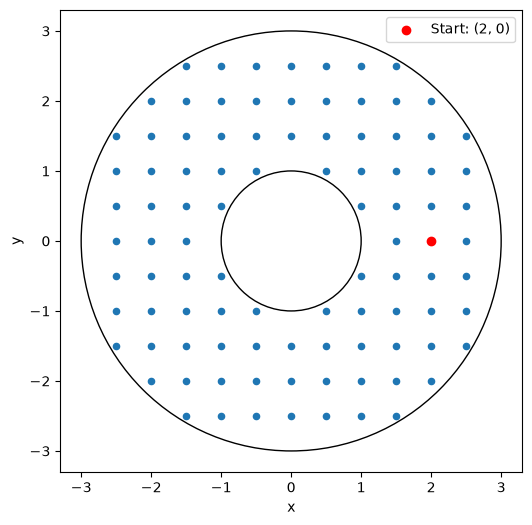

In [2]:
interior = (R > 1) & (R < 3)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(X[interior], Y[interior], s=20)

ax.add_patch(plt.Circle((0, 0), 1, fill=False, color="black")) # Inner circle
ax.add_patch(plt.Circle((0, 0), 3, fill=False, color="black")) # Outer circle

ax.scatter(2, 0, color="red", label="Start: (2, 0)", zorder=3)

ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()

plt.show()

### 5.2 Transitions and node classification

`steps` stores four **index increments**, chosen with probability $1/4$. A change of one index corresponds to a physical displacement of length $h$.

`classify_node` implements the following rule:

1. Assign 4 when $r\le1$, and 6 when $r\ge3$.
2. For $1<r<3$, stop if any nearest neighbor has radius $\le1$ or $\ge3$. Assign the nearest circle's value: 4 if $r-1\le3-r$, otherwise 6.
3. Return `None` at all remaining nodes, meaning that the walk continues.

The physically accessible absorbing layer lies inside the annulus, within distance **at most** $h$ of a circle. Auxiliary labels outside the annulus are convenient for storage, but are not values of the PDE solution outside its domain. `np.any` asks whether at least one neighbor satisfies the stopping condition.

### Why a first-order error bound is appropriate here

The continuous solution is smooth on a neighborhood of the closed annulus. On accessible absorbing nodes, the boundary mismatch satisfies
$$|g_N(z)-u(z)|\le C_bh,$$
because $|\nabla u|$ is bounded and the nearest true boundary is at distance at most $h$. At continuation nodes, the local mean-value defect
$$\delta_h(z)=\frac14\sum_{w\sim z}u(w)-u(z)=\frac{h^2}{4}\Delta_hu(z)$$
satisfies $|\delta_h(z)|\le C_ih^4$ uniformly for sufficiently small $h$.

The stopped-walk identity proved in Section 5.3 bounds $\mathbb E_z[\tau_N]\le9/h^2$, since all accessible states have radius at most 3. Telescoping conditional expectations up to absorption therefore gives
$$U^{(N)}(z)-u(z)=\mathbb E_z[g_N(X_{\tau_N})-u(X_{\tau_N})]
+\mathbb E_z\!\left[\sum_{k<\tau_N}\delta_h(X_k)\right],$$
and consequently
$$\boxed{\sup_{z\in I_N}|U^{(N)}(z)-u(z)|\le C_bh+9C_ih^2=O(h).}$$
Passing from bounded stopping times to $\tau_N$ is justified by bounded positions, bounded defects, and finite expected absorption time. This is an **upper bound**, not a claim that the error is asymptotically equal to a nonzero constant times $h$.

**Intuition.** Boundary nodes assigned 4 lie slightly outside the true inner circle and therefore underestimate the exact local value; nodes assigned 6 near the outer circle overestimate it. These contributions can partially cancel at the target. Their geometry changes irregularly with $N$, so monotonic decay is not guaranteed. The argument concerns the ideal grid in exact arithmetic; the implementation also has floating-point roundoff near radius comparisons.

In [3]:
steps = np.array([
    [ 1,  0],
    [-1,  0],
    [ 0,  1],
    [ 0, -1]
])

**Classifier implementation.** The function receives physical coordinates and the grid spacing. It returns either a prescribed boundary value or `None`.

In [4]:
def classify_node(x, y, h):
    r = np.sqrt(x**2 + y**2)

    # Points on the circles or outside the annulus
    if r <= 1:
        return 4.0
    if r >= 3:
        return 6.0

    # Coordinates of the four neighbors
    neighbors = np.array([
        [x + h, y],
        [x - h, y],
        [x, y + h],
        [x, y - h]
    ])

    radii = np.sqrt(neighbors[:, 0]**2 + neighbors[:, 1]**2)

    # Does any neighbor touch or cross the boundary?
    touches_boundary = np.any((radii <= 1) | (radii >= 3))

    if touches_boundary:
        if r - 1 <= 3 - r:
            return 4.0
        else:
            return 6.0

    return None

**Classification check.** For $N=12$ and $h=0.5$, $(2,0)$ is a continuation node. The node $(1.5,0)$ has a neighbor at radius 1 and receives value 4; $(2.5,0)$ has a neighbor at radius 3 and receives value 6. These expected results depend on the current spacing.

In [5]:
print(classify_node(2, 0, h))    # None
print(classify_node(1.5, 0, h))  # 4.0
print(classify_node(2.5, 0, h))  # 6.0

None
4.0
6.0


**Starting node.** `argmin` returns the index of the closest coordinate. Minimizing the coordinate distances separately gives a nearest Euclidean node on a Cartesian product grid. For the resolutions used here, the target is exactly $(2,0)$.

In [6]:
i0 = np.argmin(np.abs(x - 2))
j0 = np.argmin(np.abs(y - 0))

print("Starting point:", (x[i0], y[j0]))

Starting point: (np.float64(2.0), np.float64(0.0))


### 5.3 One walk and the first estimate

`walk` classifies the current node, returns its boundary value if it is absorbing, or samples a direction and updates the indices otherwise. `rng.integers(0,4)` selects 0, 1, 2, or 3. The generator is initialized outside the function; resetting the same seed inside every walk would repeat trajectories instead of producing new samples.

### Expected number of steps

At a continuation node $z$, symmetry of the four increments implies
$$\mathbb E[|X_{k+1}|^2-|X_k|^2\mid X_k=z]=h^2.$$
Thus $|X_{n\wedge\tau_N}|^2-h^2(n\wedge\tau_N)$ is a martingale. Taking expectations for finite $n$, then using bounded convergence for positions and monotone convergence for the stopping times, yields
$$\boxed{\mathbb E_z[\tau_N]=\frac{\mathbb E_z|X_{\tau_N}|^2-|z|^2}{h^2}.}$$
This also gives a uniform $O(h^{-2})$ upper bound. For the target $(2,0)$, replacing exit radii by 1 and 3 gives the fine-grid approximation
$$\mathbb E[\tau_N]\approx\frac{1+8p_N-4}{h^2}.$$
As the grid is refined, $p_N\to\log2/\log3\approx0.631$, so the leading scale is about $2.05/h^2\approx0.057N^2$. These are asymptotic estimates, not measured step counts; the current simulation does not record path lengths.

**Intuition.** For an unbiased walk, a typical displacement after $k$ steps is of order $h\sqrt{k}$. Traversing a fixed physical distance therefore takes order $h^{-2}$ steps.

In [7]:
rng = np.random.default_rng(42)

**Single-walk implementation.** The state consists of two integer indices. Each call returns one realization of the exit payoff.

In [8]:
def walk(i0, j0, x, y, h, rng):
    i, j = i0, j0

    while True:
        value = classify_node(x[i], y[j], h)

        if value is not None:
            return value

        direction = rng.integers(0, 4)
        di, dj = steps[direction]

        i += di
        j += dj

**First Monte Carlo experiment.** `empty` allocates uninitialized memory; every entry is filled before taking the mean. The seed is not reset between walks.

In [9]:
M = 1000
outcomes = np.empty(M)

for k in range(M):
    outcomes[k] = walk(i0, j0, x, y, h, rng)

estimate = np.mean(outcomes)

print("Monte Carlo estimate:", estimate)

Monte Carlo estimate: 5.128


**Interpreting the first estimate.** The following diagnostic compares the sample mean with the continuous reference and estimates the Monte Carlo standard error. On the coarse grid, a substantial discrepancy may be caused by discretization. A single sample mean and its standard error cannot determine the exact split; that requires the discrete solver introduced below.

In [10]:
exact_value = 4 + 2 * np.log(2) / np.log(3)
sample_se = outcomes.std(ddof=1) / np.sqrt(len(outcomes))
print(f"Continuous target: {exact_value:.9f}")
print(f"Monte Carlo estimate: {estimate:.9f}")
print(f"Total absolute error: {abs(estimate - exact_value):.9f}")
print(f"Estimated sampling standard error: {sample_se:.9f}")

Continuous target: 5.261859507
Monte Carlo estimate: 5.128000000
Total absolute error: 0.133859507
Estimated sampling standard error: 0.031378346


### 5.4 Total error as the grid is refined

`simulate(N,M,rng)` rebuilds the grid, chooses the starting node, and runs $M$ independent walks in the probabilistic model. The returned outcomes are kept so that subsequent cells can compute means and variability.

We evaluate $|\widehat U_{N,M}-u(2,0)|$ for several resolutions with $M=10000$ fixed. The Monte Carlo standard error is at most $0.01$, so once discretization reaches a comparable scale, this graph mixes the two mechanisms. It should not be used alone to infer the deterministic convergence order.

In [11]:
def simulate(N, M, rng):
    h = 6 / N
    x = np.linspace(-3, 3, N + 1)
    y = np.linspace(-3, 3, N + 1)

    i0 = np.argmin(np.abs(x - 2))
    j0 = np.argmin(np.abs(y))

    outcomes = np.empty(M)

    for k in range(M):
        outcomes[k] = walk(i0, j0, x, y, h, rng)

    return outcomes

**Compute the grid-refinement experiment.** Each call constructs the appropriate grid; the result is compared with the continuous target.

In [12]:
exact_value = 4 + 2 * np.log(2) / np.log(3)
rng = np.random.default_rng(42)

N_values = np.array([12, 24, 36, 48])
M_fixed = 10000

N_errors = np.empty(len(N_values))

for k, N in enumerate(N_values):
    outcomes = simulate(N, M_fixed, rng)
    estimate = outcomes.mean()

    N_errors[k] = abs(estimate - exact_value)

    print(f"N = {N}, estimate = {estimate:.5f}, "
          f"error = {N_errors[k]:.5f}")

N = 12, estimate = 5.15260, error = 0.10926
N = 24, estimate = 5.23460, error = 0.02726
N = 36, estimate = 5.25080, error = 0.01106
N = 48, estimate = 5.25360, error = 0.00826


**Plot total error versus resolution.** The points combine geometric bias with sampling variation.

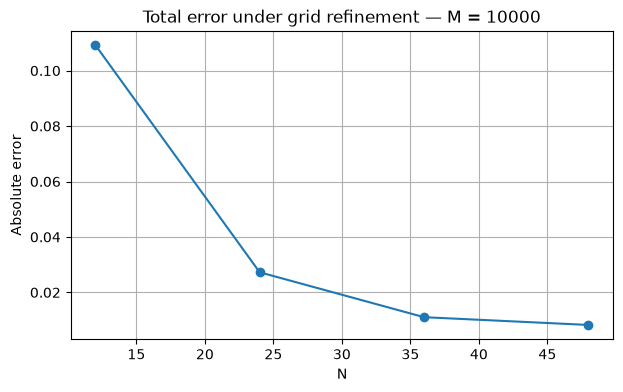

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(N_values, N_errors, "o-")
plt.xlabel("N")
plt.ylabel("Absolute error")
plt.title(f"Total error under grid refinement — M = {M_fixed}")
plt.grid(True)
plt.show()

### 5.5 Total error as the sample size increases

With $N=48$ fixed, one collection of 20,000 walks provides cumulative means for several values of $M$. Each mean is a valid estimator, but estimates at different $M$ share samples and are correlated.

The dashed $1/\sqrt M$ curve bounds the **standard error**, since $\sigma_N\le1$. It is not a bound on the observed absolute error, nor on total error relative to the continuous solution. The exact statistical RMSE is $\sigma_N/\sqrt M$; the total RMSE is $\sqrt{\sigma_N^2/M+b_N^2}$. At large $M$, the latter approaches $|b_N|$.

**Code.** `cumsum` gives partial sums. Because indexing starts at zero, the mean of the first $M$ outcomes is stored at position `M-1`.

In [14]:
N_fixed = 48
M_values = np.array([1000, 2000, 5000, 10000, 20000])

outcomes = simulate(N_fixed, M_values[-1], rng)

cumulative_means = np.cumsum(outcomes) / np.arange(1, len(outcomes) + 1)

M_estimates = cumulative_means[M_values - 1]
M_errors = np.abs(M_estimates - exact_value)

**Plot total error versus sample size.** The reference curve describes statistical scale, while the observed error also includes discretization.

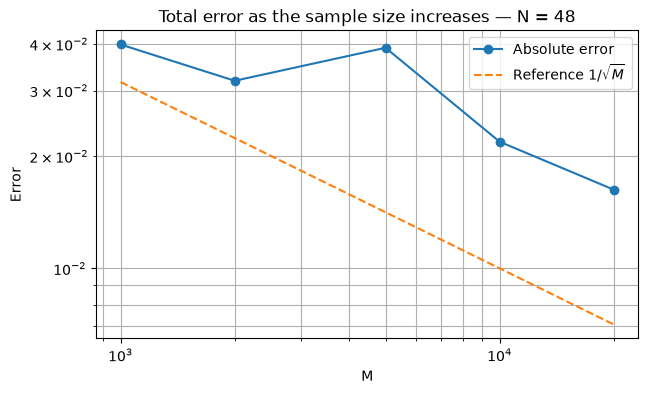

In [15]:
plt.figure(figsize=(7, 4))

plt.loglog(M_values, M_errors, "o-", label="Absolute error")
plt.loglog(
    M_values,
    1 / np.sqrt(M_values),
    "--",
    label=r"Reference $1/\sqrt{M}$"
)

plt.xlabel("M")
plt.ylabel("Error")
plt.title(f"Total error as the sample size increases — N = {N_fixed}")
plt.grid(True, which="both")
plt.legend()
plt.show()

### 5.6 Sparse reference solution

`solve_discrete(N)` uses exactly the same node classification as the walk. It numbers the continuation nodes, constructs the diagonal and neighbor entries of $A$, accumulates absorbing-neighbor values in the right-hand side, and solves with `spsolve`.

`lil_matrix` supports incremental assembly. The conversion to CSR provides a sparse representation for solving. `NaN` marks unknown grid values before the solve. The discrete maximum principle implies invertibility as shown in Section 2; a residual check below also verifies that the computed vector satisfies the assembled equations numerically.

The default return value is the solution at the target. With `return_field=True`, the function returns the full array, which we later use to separate errors at every continuation node. Labels outside the annulus are only storage values and must be masked in physical plots.

In [16]:
def solve_discrete(N, return_field=False):
    h = 6 / N
    x = np.linspace(-3, 3, N + 1)
    y = np.linspace(-3, 3, N + 1)

    values = np.empty((N + 1, N + 1))
    interior_nodes = []

    for i in range(N + 1):
        for j in range(N + 1):
            value = classify_node(x[i], y[j], h)

            if value is None:
                interior_nodes.append((i, j))
                values[i, j] = np.nan
            else:
                values[i, j] = value

    # Assign one unknown to each continuation node
    index = {
        node: k
        for k, node in enumerate(interior_nodes)
    }

    count = len(interior_nodes)
    A = lil_matrix((count, count), dtype=float)
    b = np.zeros(count)

    for k, (i, j) in enumerate(interior_nodes):
        A[k, k] = 4

        for di, dj in steps:
            neighbor = (i + di, j + dj)

            if neighbor in index:
                A[k, index[neighbor]] -= 1
            else:
                b[k] += values[neighbor]

    A = A.tocsr()
    solution = spsolve(A, b)
    residual = np.max(np.abs(A @ solution - b))
    if residual > 1e-9 * max(1.0, np.max(np.abs(b))):
        raise RuntimeError(f"Linear-system residual too large: {residual}")

    for k, (i, j) in enumerate(interior_nodes):
        values[i, j] = solution[k]

    i0 = np.argmin(np.abs(x - 2))
    j0 = np.argmin(np.abs(y))

    return values if return_field else values[i0, j0]

**Numerical comparison at a fixed grid.** The following cell reports continuous, discrete, and sampled values, followed by signed and absolute error components.

In [17]:
N = 48
M = 10000

u_exact = 4 + 2 * np.log(2) / np.log(3)
u_discrete = solve_discrete(N)

outcomes = simulate(N, M, rng)
u_mc = outcomes.mean()

error_mc = u_mc - u_discrete
discretization_error = u_discrete - u_exact
error_total = u_mc - u_exact

print(f"Continuous solution: {u_exact:.6f}")
print(f"Discrete solution: {u_discrete:.6f}")
print(f"MC estimate:     {u_mc:.6f}")
print()
print(f"Absolute error MC:             {abs(error_mc):.6f}")
print(f"Absolute error discretization: {abs(discretization_error):.6f}")
print(f"Absolute error total:          {abs(error_total):.6f}")
print(f"Signed MC error:             {error_mc:+.9f}")
print(f"Signed discretization bias: {discretization_error:+.9f}")
print(f"Signed total error:          {error_total:+.9f}")
assert np.isclose(error_total, error_mc + discretization_error)

Continuous solution: 5.261860
Discrete solution: 5.252739
MC estimate:     5.242000

Absolute error MC:             0.010739
Absolute error discretization: 0.009121
Absolute error total:          0.019860
Signed MC error:             -0.010738781
Signed discretization bias: -0.009120726
Signed total error:          -0.019859507


**Interpreting the decomposition.** The printed signed components obey
$$\widehat U_{N,M}-u(2,0)=(\widehat U_{N,M}-U_N)+(U_N-u(2,0)).$$
If both have the same sign, their absolute values add. With opposite signs they can partially cancel, so a Monte Carlo realization can happen to be closer to the continuous solution than the discrete reference is. This accidental cancellation does not make Monte Carlo unbiased for the continuous value or remove the discretization bias.

### 5.7 Separating the two errors

**Discretization.** Compute $|U_N-u(2,0)|$ by solving the deterministic system at each resolution. There is no Monte Carlo noise in this curve. Irregular behavior can result from changes in the stair-step boundary and cancellation between inner and outer boundary effects. The $O(h)$ bound from Section 5.2 does not imply a monotone curve or an exact power law at each resolution.

**Monte Carlo.** Fix a resolution and compare the sample means with $U_N$, rather than with the continuous solution. The only relevant discrepancy is then sampling error, apart from the much smaller numerical solver error. Its theoretical RMSE is $\sqrt{(U_N-4)(6-U_N)/M}$.

In [18]:
rng = np.random.default_rng(42)
u_exact = 4 + 2 * np.log(2) / np.log(3)

# 1. Discretization error: vary N
N_values = np.array([12, 18, 24, 30, 36, 42, 48])

discrete_solutions = np.array([
    solve_discrete(N) for N in N_values
])

discretization_errors = np.abs(discrete_solutions - u_exact)

# 2. Monte Carlo error: fix N and vary M
N_fixed = 48
u_discrete = discrete_solutions[-1]

M_values = np.array([1000, 2000, 5000, 10000, 20000])
outcomes = simulate(N_fixed, M_values[-1], rng)

cumulative_means = np.cumsum(outcomes) / np.arange(1, len(outcomes) + 1)
estimates = cumulative_means[M_values - 1]

mc_errors = np.abs(estimates - u_discrete)

# Theoretical root mean squared Monte Carlo error
rmse_mc = np.sqrt(
    (u_discrete - 4) * (6 - u_discrete) / M_values
)

**Plot the separated errors.** The deterministic error is shown on the left and a single Monte Carlo realization on the right.

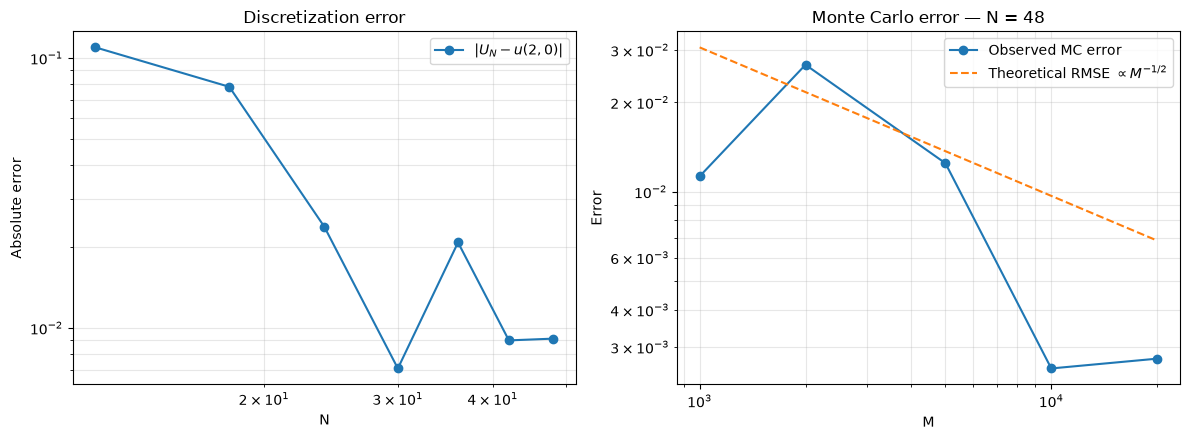

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].loglog(
    N_values, discretization_errors,
    "o-", label=r"$|U_N-u(2,0)|$"
)
axes[0].set_xlabel("N")
axes[0].set_ylabel("Absolute error")
axes[0].set_title("Discretization error")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

axes[1].loglog(
    M_values, mc_errors,
    "o-", label="Observed MC error"
)
axes[1].loglog(
    M_values, rmse_mc,
    "--", label=r"Theoretical RMSE $\propto M^{-1/2}$"
)
axes[1].set_xlabel("M")
axes[1].set_ylabel("Error")
axes[1].set_title(f"Monte Carlo error — N = {N_fixed}")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.8 Vectorized simulation

`prepare_mc_grid` classifies the grid once. It stores 4 or 6 at absorbing nodes and `NaN` at continuation nodes. This replaces repeated geometric calculations with array lookups.

`simulate_vectorized` stores all walkers' positions in arrays `i` and `j`. `active` contains the original identifiers of unfinished walks. Every iteration samples a direction for each active walker, advances it, stores newly completed outcomes, and removes completed walkers from the active set. Outcomes retain their original ordering, rather than being ordered by finishing time.

The loop runs until the longest trajectory finishes, but total movement work is proportional to $\sum_m\tau_N^{(m)}$. The probability model is unchanged. With a fixed seed, vectorized and sequential versions need not agree path by path because random numbers are consumed in different orders.

Independence is provided by independent random choices across walkers in the mathematical model; it is **not** a consequence of the Markov property. On the computer, a pseudo-random generator approximates these choices.

In [20]:
def prepare_mc_grid(N):
    h = 6 / N
    x = np.linspace(-3, 3, N + 1)
    y = np.linspace(-3, 3, N + 1)

    boundary = np.full((N + 1, N + 1), np.nan)

    for i in range(N + 1):
        for j in range(N + 1):
            value = classify_node(x[i], y[j], h)

            if value is not None:
                boundary[i, j] = value

    i0 = np.argmin(np.abs(x - 2))
    j0 = np.argmin(np.abs(y))

    return boundary, i0, j0


def simulate_vectorized(boundary, i0, j0, M, rng):
    if not np.isnan(boundary[i0, j0]):
        return np.full(M, boundary[i0, j0])

    i = np.full(M, i0, dtype=int)
    j = np.full(M, j0, dtype=int)

    outcomes = np.empty(M)
    active = np.arange(M)

    while active.size > 0:
        directions = rng.integers(0, 4, size=active.size)

        i[active] += steps[directions, 0]
        j[active] += steps[directions, 1]

        values = boundary[i[active], j[active]]
        finished = ~np.isnan(values)

        outcomes[active[finished]] = values[finished]
        active = active[~finished]

    return outcomes

### 5.9 Extended deterministic refinement study

Before the final comparison, extend the grid study to $N=384$. All resolutions remain multiples of 6. These errors are computed without Monte Carlo noise. The printed signed biases make cancellations visible; a change in sign is compatible with the uniform $O(h)$ bound.

In [21]:
N_values = np.array([12, 18, 24, 36, 48, 66, 90, 120, 156, 198, 252, 312, 384])
u_exact = 4 + 2 * np.log(2) / np.log(3)
discrete_solutions = []
for grid_N in N_values:
    discrete_value = solve_discrete(grid_N)
    discrete_solutions.append(discrete_value)
    print(f"N = {grid_N:3d}, discrete value = {discrete_value:.9f}, signed bias = {discrete_value - u_exact:+.6e}")
discretization_errors = np.abs(np.array(discrete_solutions) - u_exact)

N =  12, discrete value = 5.152394775, signed bias = -1.094647e-01
N =  18, discrete value = 5.183662289, signed bias = -7.819722e-02
N =  24, discrete value = 5.238129839, signed bias = -2.372967e-02
N =  36, discrete value = 5.241133324, signed bias = -2.072618e-02
N =  48, discrete value = 5.252738781, signed bias = -9.120726e-03
N =  66, discrete value = 5.252658995, signed bias = -9.200512e-03
N =  90, discrete value = 5.252266436, signed bias = -9.593071e-03
N = 120, discrete value = 5.256072408, signed bias = -5.787099e-03
N = 156, discrete value = 5.258058597, signed bias = -3.800910e-03
N = 198, discrete value = 5.258974189, signed bias = -2.885318e-03
N = 252, discrete value = 5.259575986, signed bias = -2.283521e-03
N = 312, discrete value = 5.259501759, signed bias = -2.357749e-03
N = 384, discrete value = 5.260138016, signed bias = -1.721491e-03


### 5.10 Repeated Monte Carlo experiments

For fixed $N=96$, perform $R=12$ repetitions. Each uses a new collection of walks and cumulative means for $M$ between $10^3$ and $2\cdot10^5$. Estimate
$$\widehat{\operatorname{RMSE}}(M)=\sqrt{\frac1R\sum_{r=1}^R(\widehat U_{N,M}^{(r)}-U_N)^2}.$$
The average inside the square root is unbiased for MSE. Its square root is generally **not** unbiased for RMSE, but converges to it as $R\to\infty$. The plotted empirical curve remains random for finite $R$.

If the replicate errors are approximately independent centered Gaussian variables, the delta method gives an approximate relative standard deviation $1/\sqrt{2R}$ for empirical RMSE. For $R=12$ this is about 20%; it is a heuristic uncertainty scale, not an exact guarantee. At different $M$, the estimates are correlated because they use common prefixes within each repetition.

**Code.** `errors` has one row per repetition and one column per sample size. `mean(..., axis=0)` averages over repetitions. The seed is set once before the loop. Wait for every repetition to finish before plotting.

In [22]:
rng = np.random.default_rng(42)

N_fixed = 96
u_discrete = solve_discrete(N_fixed)
boundary, i0, j0 = prepare_mc_grid(N_fixed)

M_values = np.unique(
    np.geomspace(1000, 200000, 30).astype(int)
)

repetitions = 12
errors = np.empty((repetitions, len(M_values)))

for r in range(repetitions):
    outcomes = simulate_vectorized(
        boundary, i0, j0, M_values[-1], rng
    )

    cumulative_means = (
        np.cumsum(outcomes)
        / np.arange(1, len(outcomes) + 1)
    )

    errors[r] = cumulative_means[M_values - 1] - u_discrete

    print(f"Repetition {r + 1}/{repetitions} completed")

empirical_rmse = np.sqrt(np.mean(errors**2, axis=0))

theoretical_rmse = np.sqrt(
    (u_discrete - 4) * (6 - u_discrete) / M_values
)

print("Done: the plotting cell can now be run.")

Repetition 1/12 completed
Repetition 2/12 completed
Repetition 3/12 completed
Repetition 4/12 completed
Repetition 5/12 completed
Repetition 6/12 completed
Repetition 7/12 completed
Repetition 8/12 completed
Repetition 9/12 completed
Repetition 10/12 completed
Repetition 11/12 completed
Repetition 12/12 completed
Done: the plotting cell can now be run.


**Final convergence figure.** The left panel uses the extended resolution study. Faint curves show individual absolute sampling errors; the solid curve is empirical RMSE and the dashed curve is its theoretical counterpart.

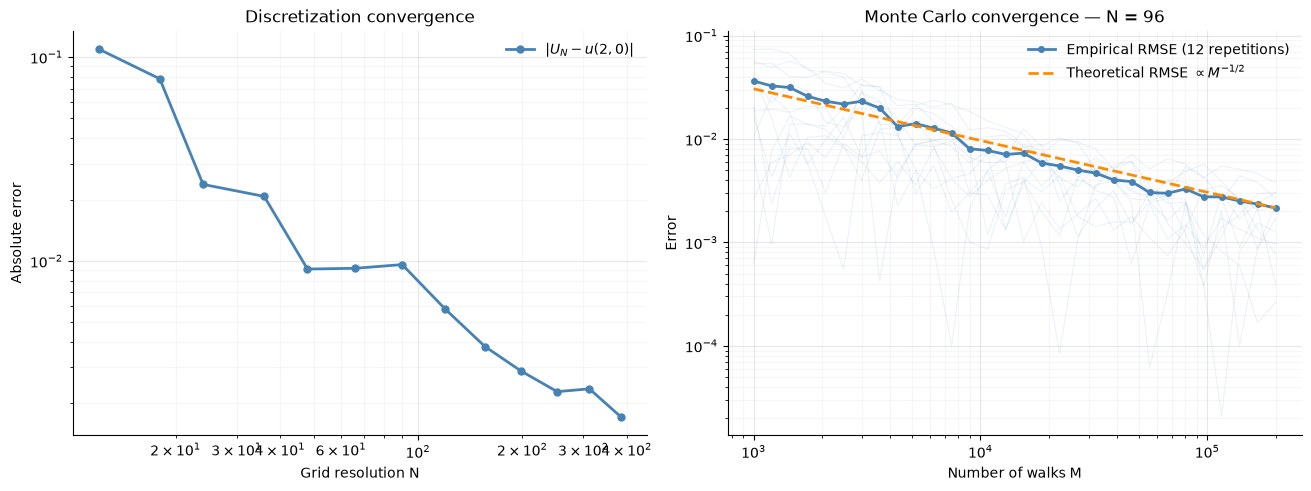

In [23]:
fig, axes = plt.subplots(
    1, 2, figsize=(13, 4.8), constrained_layout=True
)

axes[0].loglog(
    N_values, discretization_errors,
    "o-", color="steelblue", linewidth=2, markersize=5,
    label=r"$|U_N-u(2,0)|$"
)

axes[0].set(
    xlabel="Grid resolution N",
    ylabel="Absolute error",
    title="Discretization convergence"
)

# Show individual repetitions faintly to display variability
for r in range(repetitions):
    axes[1].loglog(
        M_values, np.abs(errors[r]),
        color="steelblue", alpha=0.10, linewidth=0.8
    )

axes[1].loglog(
    M_values, empirical_rmse,
    "o-", color="steelblue", linewidth=2, markersize=4,
    label=f"Empirical RMSE ({repetitions} repetitions)"
)

axes[1].loglog(
    M_values, theoretical_rmse,
    "--", color="darkorange", linewidth=2,
    label=r"Theoretical RMSE $\propto M^{-1/2}$"
)

axes[1].set(
    xlabel="Number of walks M",
    ylabel="Error",
    title=f"Monte Carlo convergence — N = {N_fixed}"
)

for ax in axes:
    ax.grid(True, which="major", alpha=0.3)
    ax.grid(True, which="minor", alpha=0.1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False)

plt.show()

### 5.11 Reconstructing the full field

The representation $U^{(N)}(z)=\mathbb E_z[g_N(X_{\tau_N})]$ holds at every continuation node. We therefore launch $M$ walks from each node to obtain a grid-valued estimator $\widehat U^{(N)}_M(z)$.

**Code.** `argwhere` lists continuation-node indices. `repeat` creates $M$ walkers per starting node. The results are stored by original walker identifier, so `reshape(K_N,M).mean(axis=1)` averages the correct group for each starting node. Absorbing-node values are copied directly from the data, not estimated by Monte Carlo.

The total number of walkers is $K_NM$. For a fixed geometry, total expected movement work scales as $O(MN^4)$, since $K_N=O(N^2)$ and the mean absorption time is $O(N^2)$. Keeping all walkers at once uses memory of order $K_NM$; batching would reduce peak memory. This example deliberately uses a moderate grid.

At an individual node, the statistical standard error is at most $1/\sqrt M$, about 0.0224 for $M=2000$. This is **not a bound on the observed nodewise error**, and the maximum over many nodes can be substantially larger. To identify geometric bias directly, the plots below also compute the complete deterministic discrete field.

In [24]:
def estimate_field_mc(boundary, M, rng):
    # Estimate all continuation-node values using M walks per node.
    nodes = np.argwhere(np.isnan(boundary))          # (n, 2): continuation-node indices (i, j)
    n = len(nodes)

    i = np.repeat(nodes[:, 0], M)                 # position of each walker
    j = np.repeat(nodes[:, 1], M)
    res = np.empty(n * M)
    active = np.arange(n * M)

    while active.size > 0:
        d = rng.integers(0, 4, size=active.size)
        i[active] += steps[d, 0]
        j[active] += steps[d, 1]

        v = boundary[i[active], j[active]]
        done = ~np.isnan(v)
        res[active[done]] = v[done]
        active = active[~done]

    field = boundary.copy()                          # retain prescribed values at absorbing nodes
    field[nodes[:, 0], nodes[:, 1]] = res.reshape(n, M).mean(axis=1)
    return field

**Compute and compare the full fields.** All error maps share one symmetric color scale. Numerical metrics below use continuation nodes only. The first panel distinguishes sampled continuation nodes from prescribed absorbing nodes.

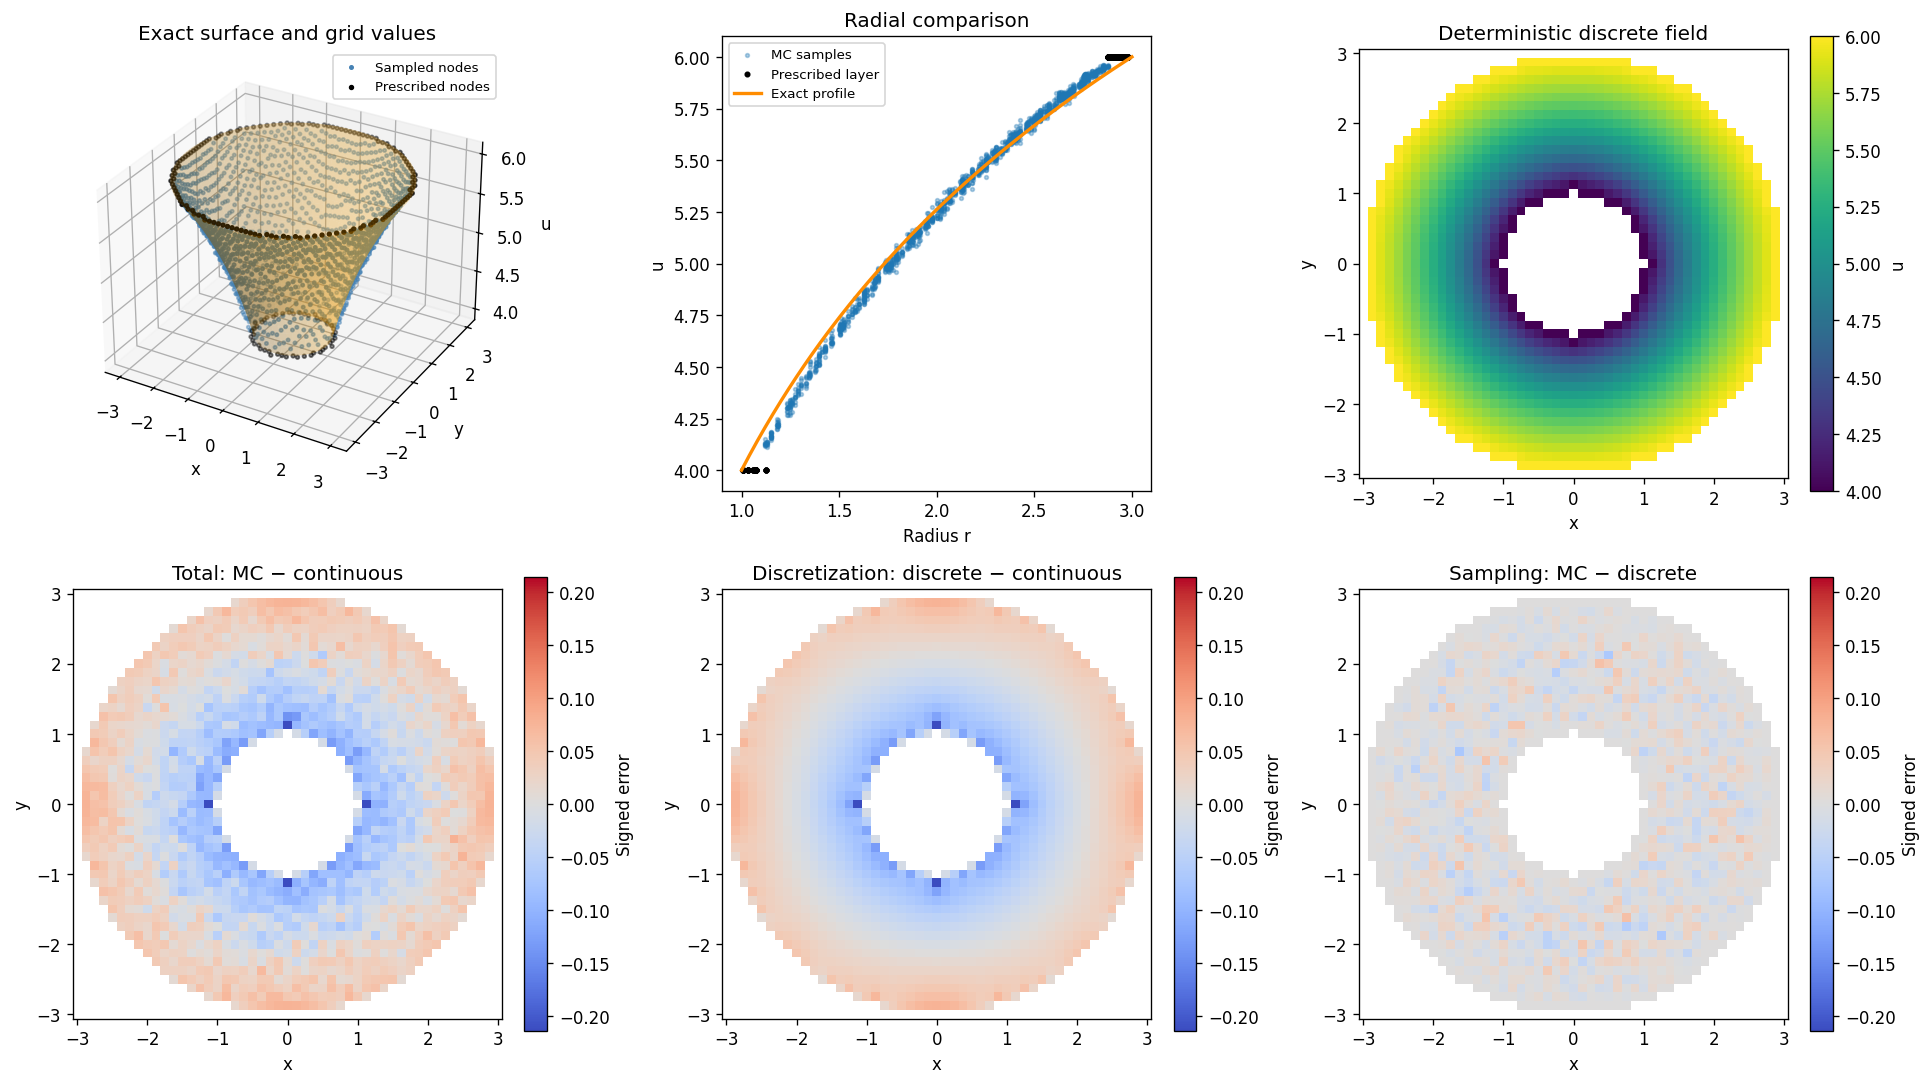

Continuation nodes: 1412
Walks per continuation node: 2000
Upper bound on nodewise sampling standard error: 0.022361
Component             Spatial mean    Spatial RMSE    Max absolute
Total                    -0.006645        0.044699        0.141228
Discretization           -0.006681        0.040814        0.123415
Sampling                 +0.000036        0.017917        0.070059
Square root of expected spatial sampling MSE: 0.018119


In [25]:
N = 48
M = 2000
rng = np.random.default_rng(0)

boundary, _, _ = prepare_mc_grid(N)
field = estimate_field_mc(boundary, M, rng)
discrete_field = solve_discrete(N, return_field=True)

x = np.linspace(-3, 3, N + 1)
X, Y = np.meshgrid(x, x, indexing="ij")
R = np.sqrt(X**2 + Y**2)
in_annulus = (R > 1) & (R < 3)
continuation = np.isnan(boundary)
absorbing_layer = in_annulus & ~continuation
exact_field = np.full_like(R, np.nan)
exact_field[in_annulus] = 4 + 2 * np.log(R[in_annulus]) / np.log(3)

total_field_error = field - exact_field
sampling_field_error = field - discrete_field
discrete_field_error = discrete_field - exact_field
assert np.allclose(total_field_error[in_annulus],
                   (sampling_field_error + discrete_field_error)[in_annulus])

fig = plt.figure(figsize=(16, 9), constrained_layout=True)
ax = fig.add_subplot(2, 3, 1, projection="3d")
rr, theta = np.meshgrid(np.linspace(1, 3, 30), np.linspace(0, 2 * np.pi, 90))
ax.plot_surface(rr * np.cos(theta), rr * np.sin(theta),
                4 + 2 * np.log(rr) / np.log(3), alpha=0.3, color="orange", linewidth=0)
ax.scatter(X[continuation], Y[continuation], field[continuation],
           s=4, color="steelblue", label="Sampled nodes")
ax.scatter(X[absorbing_layer], Y[absorbing_layer], field[absorbing_layer],
           s=5, color="black", label="Prescribed nodes")
ax.set(xlabel="x", ylabel="y", zlabel="u", title="Exact surface and grid values")
ax.legend(fontsize=8)

ax = fig.add_subplot(2, 3, 2)
radius = np.linspace(1, 3, 200)
ax.scatter(R[continuation], field[continuation], s=5, alpha=0.35, label="MC samples")
ax.scatter(R[absorbing_layer], field[absorbing_layer], s=7, color="black", label="Prescribed layer")
ax.plot(radius, 4 + 2 * np.log(radius) / np.log(3), color="darkorange", lw=2, label="Exact profile")
ax.set(xlabel="Radius r", ylabel="u", title="Radial comparison")
ax.legend(fontsize=8)

ax = fig.add_subplot(2, 3, 3)
im = ax.pcolormesh(X, Y, np.where(in_annulus, discrete_field, np.nan),
                  cmap="viridis", vmin=4, vmax=6, shading="nearest")
ax.set_aspect("equal")
ax.set(xlabel="x", ylabel="y", title="Deterministic discrete field")
fig.colorbar(im, ax=ax, label="u")

error_maps = [total_field_error, discrete_field_error, sampling_field_error]
titles = ["Total: MC − continuous", "Discretization: discrete − continuous", "Sampling: MC − discrete"]
color_limit = max(np.max(np.abs(arr[in_annulus])) for arr in error_maps)
for panel, arr, title in zip([4, 5, 6], error_maps, titles):
    ax = fig.add_subplot(2, 3, panel)
    im = ax.pcolormesh(X, Y, np.where(in_annulus, arr, np.nan), cmap="coolwarm",
                      vmin=-color_limit, vmax=color_limit, shading="nearest")
    ax.set_aspect("equal")
    ax.set(xlabel="x", ylabel="y", title=title)
    fig.colorbar(im, ax=ax, label="Signed error")
plt.show()

print(f"Continuation nodes: {continuation.sum()}")
print(f"Walks per continuation node: {M}")
print(f"Upper bound on nodewise sampling standard error: {1 / np.sqrt(M):.6f}")
print(f"{'Component':<18} {'Spatial mean':>15} {'Spatial RMSE':>15} {'Max absolute':>15}")
for label, arr in zip(["Total", "Discretization", "Sampling"], error_maps):
    e = arr[continuation]
    print(f"{label:<18} {e.mean():+15.6f} {np.sqrt(np.mean(e**2)):15.6f} {np.max(np.abs(e)):15.6f}")
expected_spatial_mc_rmse = np.sqrt(np.mean(
    (discrete_field[continuation] - 4) * (6 - discrete_field[continuation]) / M
))
print(f"Square root of expected spatial sampling MSE: {expected_spatial_mc_rmse:.6f}")

### Reading the field comparison

The scatter plot against radius should cluster around the exact radial profile. The finite Cartesian grid does not possess full rotational symmetry, so the discrete values need not be exactly radial; sampling adds further scatter. Absorbing nodes have prescribed values 4 or 6 and appear as horizontal bands at radii slightly displaced from the true circles.

The maps separate three signed quantities:
$$\widehat U^{(N)}_M-u=(\widehat U^{(N)}_M-U^{(N)})+(U^{(N)}-u).$$
The discretization map directly reveals the deterministic geometric contribution. The sampling map shows what remains after subtracting that discrete field. At absorbing nodes, sampling error is exactly zero because the value is assigned rather than simulated.

The printed spatial RMSE is an average over **nodes in one field realization**. It differs from the expectation-based Monte Carlo RMSE at a fixed node. Unbiased sampling makes the spatial average of the cross term vanish in expectation, but it need not vanish for one realized field. All printed spatial metrics use continuation nodes only; the maps also display the absorbing layer inside the annulus.

Structured total error near the circles is consistent with boundary bias. A large isolated error alone does not establish its source; the separate maps and metrics provide the appropriate comparison.

## 6. Discussion, limitations, and next steps

### Results of the included run

At the target, the deterministic absolute error decreases from approximately 0.1095 at $N=12$ to 0.00172 at $N=384$, with intermediate increases consistent with the changing grid boundary. In the full-field experiment ($N=48$, $M=2000$), the spatial RMSE over continuation nodes is approximately 0.0408 for discretization and 0.0179 for sampling. The latter is close to 0.0181, the square root of the expected spatial sampling MSE. Thus discretization is the larger contribution in this particular field experiment; increasing the number of walks alone would leave it unchanged. These values describe the included execution and may change with the seed or numerical environment.

### Accuracy and computational trade-offs

The fixed-node total MSE equals $\sigma_N^2/M+b_N^2$. Reducing statistical standard error by a factor of ten requires one hundred times as many walks. Refining the grid or improving the boundary treatment reduces discretization bias. Increasing $M$ alone cannot remove that bias, although the two signed errors can cancel in a particular sample.

For a single target, simulation requires $M\mathbb E[\tau_N]=O(MN^2)$ expected moves. Achieving a statistical standard error of order $\varepsilon$ requires $M=O(\varepsilon^{-2})$ when the variance remains of order one. The full-field experiment is more expensive because it repeats this process across $O(N^2)$ starting nodes.

The sparse system has $K_N=O(N^2)$ unknowns and $O(K_N)$ original nonzero entries. Sparse factorization can introduce fill-in: storage and solution time are not determined by the initial nonzero count alone. For regular two-dimensional elliptic problems, suitable orderings can give direct factorization costs of order $K_N^{3/2}$. This is a contextual complexity estimate, not a measured guarantee for this call to `spsolve`. Unpreconditioned conjugate gradient is not generally linear-time; near-linear complexity requires suitable preconditioning or multigrid assumptions.

The deterministic solve obtains every interior value and avoids sampling error. Monte Carlo is useful when only a few values are needed or when independent simulation can be distributed, but it is not automatically faster in those cases. A fair timing comparison needs the same target accuracy and should account for grid setup, classification, and whether the full field is required. No measured speedup is claimed here.

### Limits of this implementation

- The boundary rule deliberately approximates the circles with an absorbing layer. The first-order bound is specific to this smooth benchmark and the stated rule.
- Floating-point comparisons near the circles may affect which side of a threshold a node falls on. Both methods use the same classifier, so they compare the same numerical model.
- Confidence intervals and statistical error formulas apply to the discrete target. They do not by themselves certify accuracy relative to the continuous PDE.
- Only a finite set of resolutions and sample sizes is tested; plots illustrate convergence rather than proving a limit.
- This implementation constructs a Cartesian grid and a boundary table. Grid-free alternatives such as walk-on-spheres would require a different algorithm and are not implemented here.
- Twelve repetitions give only a moderately stable estimate of RMSE. Increasing repetitions improves that diagnostic but does not change the $M^{-1/2}$ rate of a single estimator.

### Extension to a rectangle and nonconstant boundary data

Replace the annulus classifier and $g_N$ by a rectangle and a prescribed boundary function. The representation and sample-mean estimator remain valid for bounded data; the special two-outcome variance formula no longer applies. On a grid with unequal spacings, the probabilities must match the finite-difference stencil: each horizontal neighbor has probability
$$\frac{h_x^{-2}}{2(h_x^{-2}+h_y^{-2})},$$
and each vertical neighbor has probability
$$\frac{h_y^{-2}}{2(h_x^{-2}+h_y^{-2})}.$$
They reduce to $1/4$ when $h_x=h_y$. Compatible corner data are needed if a solution continuous on the closed rectangle is intended.

### References
1. L. C. Evans, *Partial Differential Equations*, American Mathematical Society.
2. David A. Levin and Yuval Peres, with contributions by Elizabeth L. Wilmer, *Markov Chains and Mixing Times*, 2nd ed., American Mathematical Society, 2017. [Full text](https://pages.uoregon.edu/dlevin/MARKOV/markovmixing.pdf#page=133).
3. [SciPy: `spsolve`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.spsolve.html), sparse linear system solution.

The essential arguments used in this notebook are included above, so the exposition does not depend on edition-specific page numbers.